In [5]:
import tensorflow as tf 
import numpy as np 
import matplotlib.pyplot as plt 
import time 

import transformers 
from transformers import DistilBertTokenizerFast 
from transformers import TFDistilBertForTokenClassification 

2023-07-04 23:13:07.392080: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-04 23:13:07.607174: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-07-04 23:13:07.608922: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-04 23:13:08.527200: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/kandel/MachineLearning/Deep_Learning/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Positional encoding 
#### It is necessary to provide positional encoding because unlike RNNs which takes input data serially, the transformers process the input parallely so we need to provide positional values of the input 
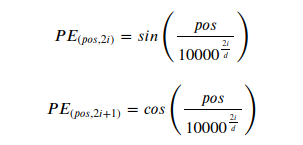


In [6]:
#First we should get the angles for calculating the sine and cosine encodings 
def get_angles(pos, k, d):
    """
    Get the angles for the positional encoding
    
    Arguments:
        pos -- Column vector containing the positions [[0], [1], ...,[N-1]]
        k --   Row vector containing the dimension span [[0, 1, 2, ..., d-1]]
        d(integer) -- Encoding size
    
    Returns:
        angles -- (pos, d) numpy array 
    """
    l = k//2 
    angles= pos/(10000**(2*l/d))
    return angles 

In [7]:
size= 8
position= 4 
pos= np.arange(position)[:, np.newaxis]
dims= np.arange(size)[np.newaxis, :]
print(get_angles(pos, dims, size))

[[0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
 [1.e+00 1.e+00 1.e-01 1.e-01 1.e-02 1.e-02 1.e-03 1.e-03]
 [2.e+00 2.e+00 2.e-01 2.e-01 2.e-02 2.e-02 2.e-03 2.e-03]
 [3.e+00 3.e+00 3.e-01 3.e-01 3.e-02 3.e-02 3.e-03 3.e-03]]


In [8]:
#Calculating the postional encoding of the input sentence 
def position_encoding(position, d): 
    """
    Precomputes a matrix with all the positional encodings 
    
    Arguments:
        positions (int) -- Maximum number of positions to be encoded 
        d (int) -- Encoding size 
    
    Returns:
        pos_encoding -- (1, position, d_model) A matrix with the positional encodings
    """
    angles= get_angles(np.arange(position)[:,np.newaxis], np.arange(d)[np.newaxis,:], d)
    
    angles[:,0::2]= np.sin(angles[:,0::2])
    
    angles[:, 1::2] = np.cos(angles[:,1::2])
    
    positional_encoding= angles[np.newaxis, ...]
    
    return tf.cast(positional_encoding, dtype= tf.float32)
    

2023-07-04 23:13:10.561471: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-07-04 23:13:10.562172: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


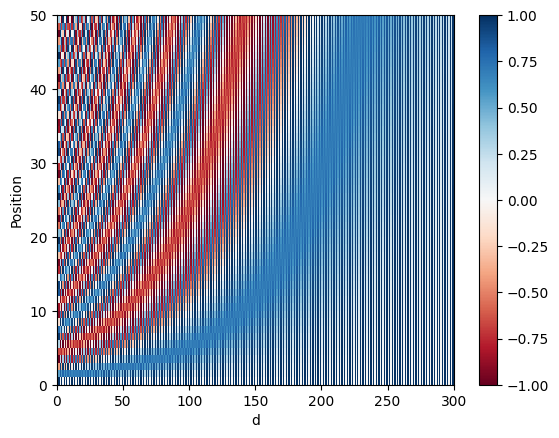

In [9]:
pos_encoding= position_encoding(50, 512)

plt.pcolormesh(pos_encoding[0], cmap= "RdBu")
plt.colorbar()
plt.xlabel("d")
plt.ylabel("Position")
plt.xlim(0,300)
plt.show()

# Masking 
#### Masking is important in order to achieve uniform sequence length before feeding it into the transformer network. Here we will use a padding mask to pad the sequences with zeros 

## Padding mask 
#### Often the input sequence will exceed the maximum length of a sequence out network can process. We can make the sequence length uniform by padding the sequence with zeros and truncating sentences that exceed the maximum length of the model. 

In [10]:
def padding_mask(decoder_token_ids):     
    """
    Creates a matrix mask for the padding cells
    
    Arguments:
        decoder_token_ids -- (n, m) matrix
    
    Returns:
        mask -- (n, 1, m) binary tensor
    """    
    seq= 1-tf.cast(tf.math.equal(decoder_token_ids,0), tf.float32)
    return seq[:,np.newaxis, :]


In [11]:
constant= tf.constant([[7., 6., 0., 0., 1.], [1., 2., 3., 0., 0.], [0., 0., 0., 4., 5.]])
print(padding_mask(constant))

tf.Tensor(
[[[1. 1. 0. 0. 1.]]

 [[1. 1. 1. 0. 0.]]

 [[0. 0. 0. 1. 1.]]], shape=(3, 1, 5), dtype=float32)


## Look ahead mask 
#### A look ahead mask helps the model pretend that it correctly predicted a part of the output and see without looking ahead it can predict the next output 

In [12]:
def look_ahead_padding(sequence_length): 
    """
    Returns a lower triangular matrix filled with ones
    
    Arguments:
        sequence_length -- matrix size
    
    Returns:
        mask -- (size, size) tensor
    """
    mask= tf.linalg.band_part(tf.ones((1, sequence_length, sequence_length)), -1, 0)
    return mask 
    

In [13]:
constant= tf.random.uniform((1,3))
look_ahead_mask= look_ahead_padding(constant.shape[1])
print(f'The original matrix is \n {constant}, \n and the look ahead mask is: \n {look_ahead_mask}')

The original matrix is 
 [[0.36415935 0.4617144  0.9175656 ]], 
 and the look ahead mask is: 
 [[[1. 0. 0.]
  [1. 1. 0.]
  [1. 1. 1.]]]


# Self-Attention 
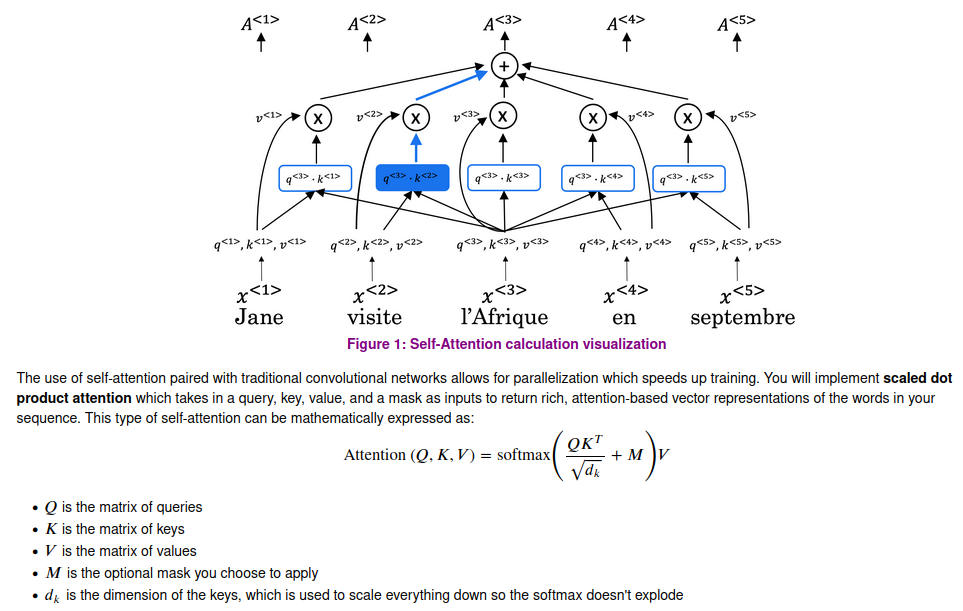

In [14]:
def scaled_dot_product_attention(q, k, v, mask): 
    """
    Calculate the attention weights.
      q, k, v must have matching leading dimensions.
      k, v must have matching penultimate dimension, i.e.: seq_len_k = seq_len_v.
      The mask has different shapes depending on its type(padding or look ahead) 
      but it must be broadcastable for addition.

    Arguments:
        q -- query shape == (..., seq_len_q, depth)
        k -- key shape == (..., seq_len_k, depth)
        v -- value shape == (..., seq_len_v, depth_v)
        mask: Float tensor with shape broadcastable 
              to (..., seq_len_q, seq_len_k). Defaults to None.

    Returns:
        output -- attention_weights
    """
    matmul_qk= tf.matmul(q,k)
    dk= tf.cast(tf.shape(k)[-1], dtype= tf.float32)
    scaled_attention_logits= matmul_qk/ tf.math.sqrt(dk)
    
    if mask is not None: 
      scaled_attention_logits += ((1-mask)* -1e9)
    
    attention_weights= tf.nn.softmax(x)
    
    attention= tf.matmul(attention_weights,v)
    
    return attention, attention_weights

# Encoder layer 
#### The transformer encoder layer pairs the self attention and convolutional neural network style of processing to improve the speed of training and passes K and V matrices to the decoder. 
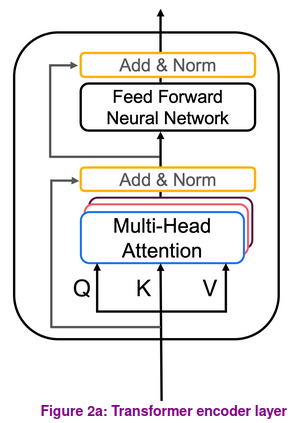

In [15]:
# Lets define the feed forward neural network of the encoder block which we will use in encoder layer 
def feed_forward_NN(embedding_dim, fully_connected_dim): 
    return tf.keras.Sequential([ tf.keras.layers.Dense(fully_connected_dim, activation= "relu"),
                                 tf.keras.layers.Dense(embedding_dim)])

In [16]:
class Encoder_layer(tf.keras.layers.Layer): 
    def __init__(self, embedding_dim, num_heads, fully_connected_dim, dropout_rate= 0.1, layernorm_eps= 1e-6): 
        super(Encoder_layer, self).__init__() 
        
        self.mha= tf.keras.layers.MultiHeadAttention(num_heads= num_heads, key_dim= embedding_dim, dropout= dropout_rate)
        
        self.ffn= feed_forward_NN(embedding_dim= embedding_dim, fully_connected_dim= fully_connected_dim)
        
        self.layernorm1= tf.keras.layers.LayerNormalization(epsilon= layernorm_eps )
        self.layernorm2= tf.keras.layers.LayerNormalization(epsilon= layernorm_eps)
        self.dropout_ffn= tf.keras.layers.Dropout(dropout_rate)
        
    def call(self, x, training, mask): 
        """ 
        Forward pass for Encoder layers
        
        Arguments: 
            x -- Tensor of shape (batch_size, input_seq_len, fully_connected_dim)
            training -- Boolean, set to True to activate the training mode for the dropout 
            mask -- Boolean mask to ensure the padding is not treated as an input 
            
        Returns: 
            encoder_layer_out -- Tensor of shape (batch_size, input_seq_len, embedding_dim)
        """
        
        #Calculate self attention using self.mha
        mha_output= self.mha(x,x,x,mask)
        
        #Apply layer normalization to the sum of input and attention output 
        skip_x_attention =self.layernorm1(x + mha_output)
        
        # Pass the output of the multi-head attention through a feed forward network 
        ffn_output= self.ffn(skip_x_attention)
        
        #Pass the output of the ffn to a dropout layer 
        ffn_output= self.dropout_ffn(ffn_output, training= training)
        
        #Apply layerNormalization to output of ffn and output of multi-head attention
        encoder_layer_out = self.layernorm2(ffn_output + skip_x_attention)
        
        return encoder_layer_out

# Full Encoder 
#### Here, we have to embedd the input, add positional encoding, and then build a full encoder. 
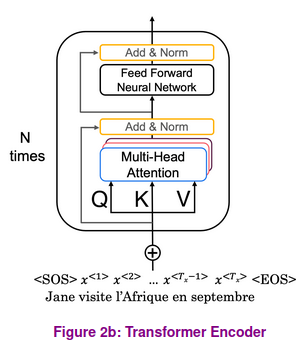

In [18]:
class Encoder(tf.keras.layers.Layer): 
    def __init__(self, num_layers, embedding_dim, num_heads, fully_connected_dim, input_vocab_size, max_position_encoding, dropout_rate= 0.1, layernorm_eps= 1e-6): 
        super(Encoder, self).__init__() 
        self.embedding_dim= embedding_dim 
        self.num_layers= num_layers 
        
        self.embedding= tf.keras.layers.Embedding(input_vocab_size, self.embedding_dim)
        self.pos_encoding= position_encoding(max_position_encoding, self.embedding_dim)
        
        self.encoder_layers= [Encoder_layer(embedding_dim= self.embedding_dim, 
                                            num_heads= num_heads, 
                                            fully_connected_dim= fully_connected_dim,
                                            dropout_rate= dropout_rate, layernorm_eps= layernorm_eps) for _ in range(self.num_layers)]
        self.dropout= tf.keras.layers.Dropout(dropout_rate)
        
    def call(self, x, training, mask): 
        """
        Forward pass for the Encoder 
        
        Arguments: 
            x -- Tensor of shape (batch_size, input_seq_len)
            training -- Boolean, set to True to activate the training for the dropout layer 
            mask -- Boolean mask to ensure that the padding is not treated as input 
        
        Returns: 
            output -- Tensor of shape (batch_size, input_seq_len, embedding_dim)
        """
        #Create a padding mask 
        seq_len= tf.shape(x)[1]
        
        #Pass the input through a embedding layer 
        x= self.embedding(x)
        
        #Scale the embedding by multiplying it with square root of embedding_dim
        x *= tf.math.sqrt(tf.cast(self.embedding_dim, dtype= tf.float32))
        
        #Add position encoding to the embedding 
        x += self.pos_encoding[:, :seq_len,:]
        
        #Pass the encoded embedding through a dropout layer 
        x = self.dropout(x, training)
        
        #pass the output through stack of encoder layers 
        for i in range(self.num_layers): 
            output = self.encoder_layers[i] (x, training, mask)
            
        return output

# Decoder Layer 
#### The decoder layer take the K and V matrices from the encoder block. The decoder layer is composed of two multi-head attention blocks, one that takes the new input and uses self attention,y and the other one that combines it with the output of the encoder followed by fully connected block.

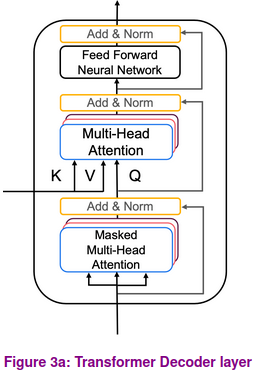

In [19]:
class Decoder_layer(tf.keras.layers.Layer): 
    def __init__(self, embedding_dim, num_heads, fully_connected_dim, dropout_rate= 0.1, layernorm_eps= 1e-6): 
        super(Encoder, self).__init__() 
        
        self.mha1= tf.keras.layers.MultiHeadAttention(num_heads= num_heads, key_dim= embedding_dim, dropout= dropout_rate)
        self.mha2 = tf.keras.layers.MultiHeadAttention(num_heads= num_heads, key_dim= embedding_dim, dropout= dropout_rate)
        
        self.ffn= feed_forward_NN(embedding_dim= embedding_dim, fully_connected_dim= fully_connected_dim)
        
        self.layernorm1= tf.keras.layers.LayerNormalization(epsilon= layernorm_eps)
        self.layernorm2= tf.keras.layers.LayerNormalization(epsilon= layernorm_eps)
        self.layernorm3= tf.keras.layers.LayerNormalization(epsilon= layernorm_eps)
        
        self.dropout= tf.keras.layers.Dropout(dropout_rate)
        
    def call(self, x, enc_output, training, look_ahead_mask, padding_mask): 
        """ 
        Forward pass for a decoder layer 
        
        Arguments: 
            x -- Tensor of shape (batch_size, target_seq_len, fully_connected_dim)
            enc_output -- Tensor of shape (batch_size, input_seq_len, fully_connected_dim)
            training -- Boolean set to True to activate the training for the dropout 
            look_ahead_mask -- Boolean mask for the target input 
            padding_mask -- Boolean mask for the second multi-head attention 
        
        Returns: 
            output --  Tensor of shape (batch_size, target_seq_len, fully_connected_dim) 
            attn_weights_block1 -- Tensor of shape (batch_size, num_heads, target_seq_length, input_seq_len)
            attn_weights_block2 -- Tensor of shape (batch_size, num_heads, target_seq_length, input_seq_len)
        """
        
        #Calculate self_attention and return attention scores as attn_weights_block1 
        attn_out1, attn_weights_block1 = self.mha1(x,x,x, look_ahead_mask)
        
        #apply layer normalization to the sum of attention output and input 
        Q1 = self.layernorm1(x + attn_out1)
        
        # Calculate the self attention using Q and K, V from encoder output 
        attn_out2, attn_weights_block2= self.mha2(Q1, enc_output, enc_output, padding_mask)
        
        # Apply layer normalization to the sum of attention output and output of first block
        attn_out2 = self.layernorm2(attn_out2 + Q1)
        
        # Pass the output through a feed forward network 
        output_ffn = self.ffn(attn_out2)
        
        #apply dropout to the ffn output 
        output_ffn = self.dropout(output_ffn, training= training)
        
        #Apply layer Normalization to the output of ffn and second block 
        output= self.layernorm3(output_ffn + attn_out2)
        
        return output, attn_weights_block1, attn_weights_block1        
        

# Full Decoder 
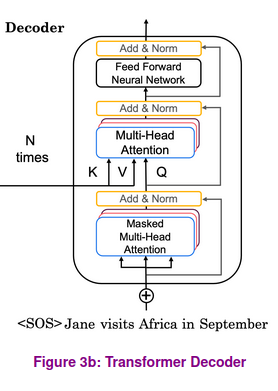

In [22]:
class Decoder(tf.keras.layers.Layer): 
    def __init__(self, num_layers, embedding_dim, num_heads, fully_connected_dim, target_vocab_size, max_position_encoding, dropout_rate= 0.1, layernorm_eps= 1e-6): 
        super(Decoder, self).__init__() 
        self.num_layers= num_layers 
        self.embedding_dim= embedding_dim 
        
        self.embedding= tf.keras.layers.Embedding(target_vocab_size, self.embedding_dim)
        self.pos_encoding= position_encoding(max_position_encoding, self.embedding_dim)
        
        self.decoder_layers= [Decoder_layer(embedding_dim= self.embedding_dim, 
                                            num_heads= num_heads, 
                                            fully_connected_dim= fully_connected_dim, 
                                            dropout_rate= dropout_rate,
                                            layernorm_eps= layernorm_eps) for _ in range(self.num_layers)]
        self.dropout= tf.keras.layers.Dropout(dropout_rate)
        
        
    def call(self, x, enc_output, training, look_ahead_mask, padding_mask):
        """
            Forward  pass for the Decoder
            
            Arguments:
                x -- Tensor of shape (batch_size, target_seq_len, fully_connected_dim)
                enc_output --  Tensor of shape(batch_size, input_seq_len, fully_connected_dim)
                training -- Boolean, set to true to activate
                            the training mode for dropout layers
                look_ahead_mask -- Boolean mask for the target_input
                padding_mask -- Boolean mask for the second multihead attention layer
            Returns:
                x -- Tensor of shape (batch_size, target_seq_len, fully_connected_dim)
                attention_weights - Dictionary of tensors containing all the attention weights
                                    each of shape Tensor of shape (batch_size, num_heads, target_seq_len, input_seq_len)
        """
        seq_len= tf.shape(x)[1]
        attention_weights= {} 
        
        #Create word embedding 
        x = self.embedding(x)
        
        #Scale the embedding by multiplying with the square root of the embedding dimension 
        x += tf.math.sqrt(tf.cast(self.embedding_dim, dtype= tf.float32))
        
        #Calculate the positional encoding and add it to embedding 
        x += self.pos_encoding[:, :seq_len, :]
        
        #Apply a dropout to x 
        x = self.dropout(x)
        
        #Pass the output to the stack of decoder layers 
        for i in range(self.num_layers): 
            output, block1, block2= self.decoder_layers[i] (x, enc_output, training, look_ahead_mask, padding_mask)
            attention_weights["decoder layer{}_block1_self_att".format(i+1)] = block1
            attention_weights["decoder_layer{}_block2_self_att".format(i+1)] = block2 
            
        return output, attention_weights

# Full transformer 
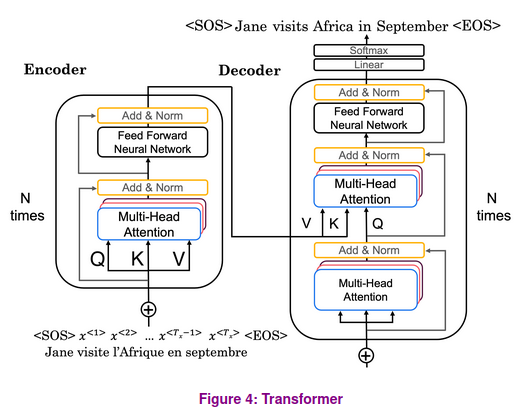

In [23]:
class Transformer(tf.keras.layers.Layer): 
    def __init__(self, num_layers, embedding_dim, num_heads, fully_connected_dim, input_vocab_size, target_vocab_size, 
                 max_position_encoding_input, max_position_encoding_target, dropout_rate= 0.1, layernorm_eps= 1e-6):
        super(Transformer. self).__init__() 
        
        self.encoder= Encoder(num_layers= num_layers, embedding_dim= embedding_dim, 
                              num_heads= num_heads, fully_connected_dim= fully_connected_dim,
                              input_vocab_size= input_vocab_size, max_position_encoding= max_position_encoding_input, 
                              dropout_rate= dropout_rate, layernorm_eps= layernorm_eps)
        
        self.decoder= Decoder(num_layers= num_layers, embedding_dim= embedding_dim, 
                              num_heads= num_heads, fully_connected_dim= fully_connected_dim, 
                              target_vocab_size= target_vocab_size, max_position_encoding= max_position_encoding_target,
                              dropout_rate= dropout_rate, layernorm_eps= layernorm_eps)
        
        self.final_layer= tf.keras.layers.Dense(target_vocab_size, activation= "softmax")
        
    def call(self, input_sentence, output_sentence, training, enc_padding_mask, look_ahead_mask, dec_padding_mask): 
        """
        Forward pass for the entire Transformer
        Arguments:
            input_sentence -- Tensor of shape (batch_size, input_seq_len, fully_connected_dim)
                              An array of the indexes of the words in the input sentence
            output_sentence -- Tensor of shape (batch_size, target_seq_len, fully_connected_dim)
                              An array of the indexes of the words in the output sentence
            training -- Boolean, set to true to activate
                        the training mode for dropout layers
            enc_padding_mask -- Boolean mask to ensure that the padding is not 
                    treated as part of the input
            look_ahead_mask -- Boolean mask for the target_input
            dec_padding_mask -- Boolean mask for the second multihead attention layer
        Returns:
            final_output -- Describe me
            attention_weights - Dictionary of tensors containing all the attention weights for the decoder
                                each of shape Tensor of shape (batch_size, num_heads, target_seq_len, input_seq_len)
        """
        #Pass the input through the encoder with appropriate arguments 
        enc_output= self.encoder(input_sentence, training, enc_padding_mask)
        
        #Pass the output sentence through decoder with appropriate arguments 
        dec_output, attention_weights = self.decoder(output_sentence, enc_output, training, look_ahead_mask, dec_padding_mask)
        
        #Pass the output through the final linear layer 
        final_output= self.final_layer(dec_output)
        
        return final_output, attention_weights

### This is how a transformer looks like. 